In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("./Sales_Prediction_Dataset.csv")

## 1. Understanding the dataset

In [3]:
df.shape

(6000, 5)

In [4]:
df.columns

Index(['Advertising_Spend', 'Social_Media_Spend', 'Store_Size', 'Footfall',
       'Monthly_Sales'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Advertising_Spend   6000 non-null   float64
 1   Social_Media_Spend  6000 non-null   float64
 2   Store_Size          6000 non-null   float64
 3   Footfall            6000 non-null   int64  
 4   Monthly_Sales       6000 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 234.5 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Advertising_Spend     0
Social_Media_Spend    0
Store_Size            0
Footfall              0
Monthly_Sales         0
dtype: int64

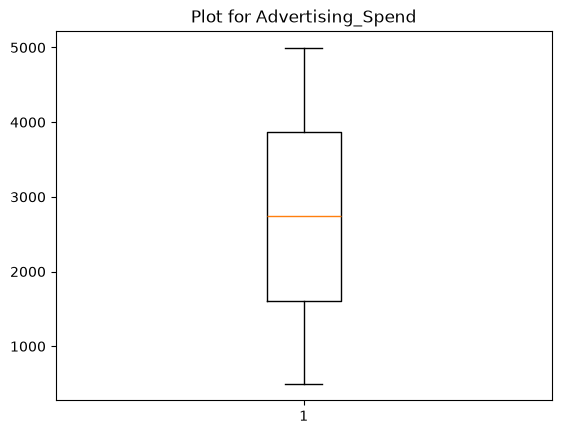

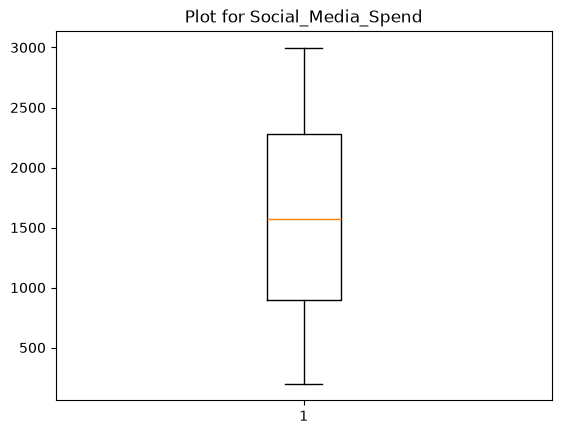

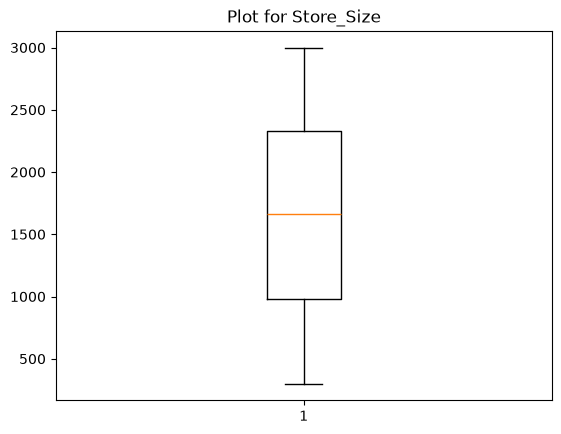

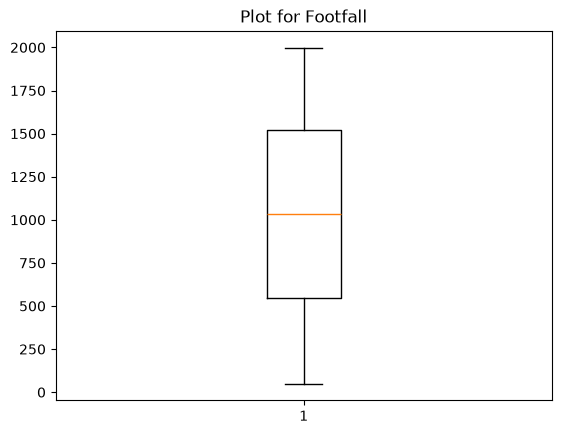

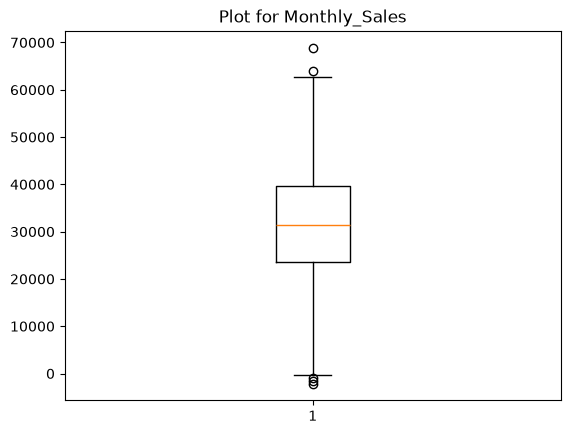

In [12]:
for col in df.columns:
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

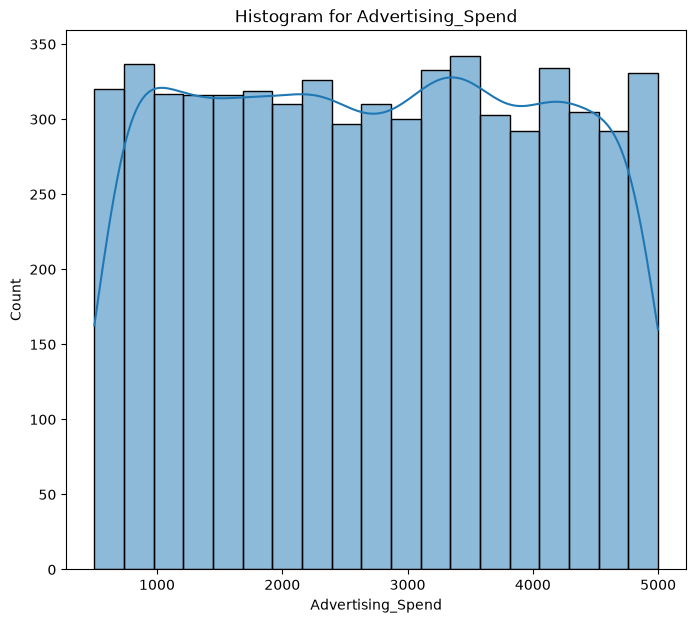

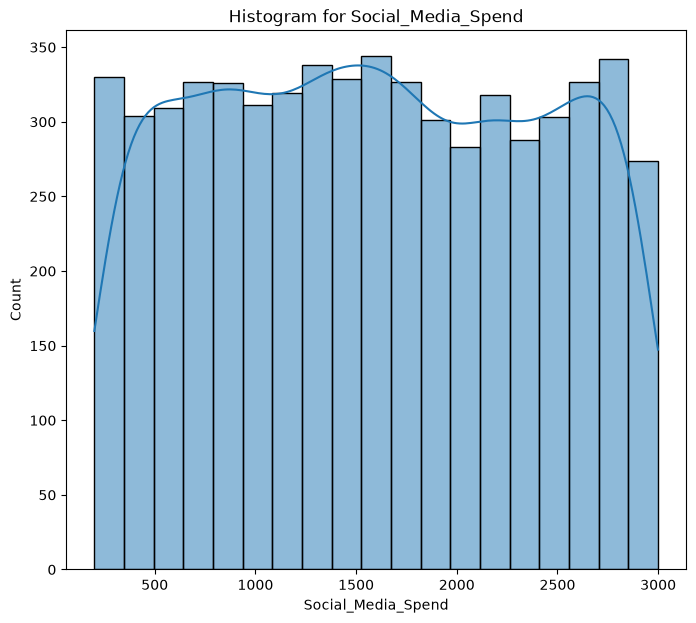

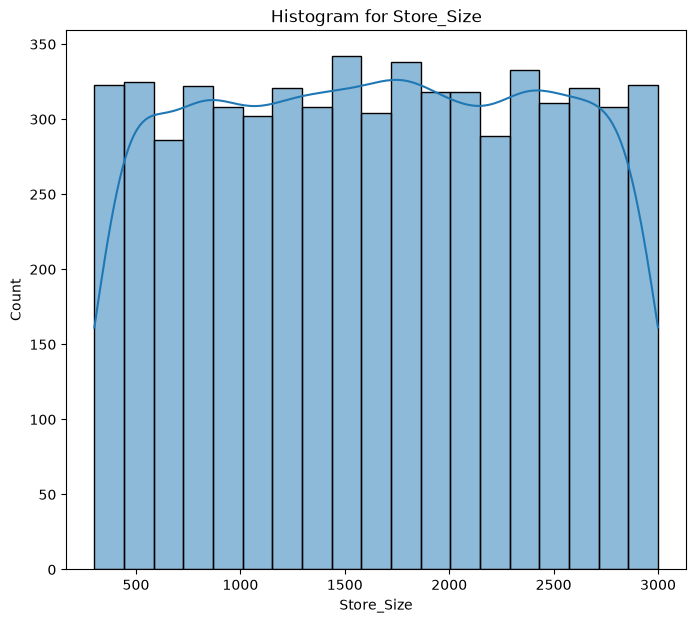

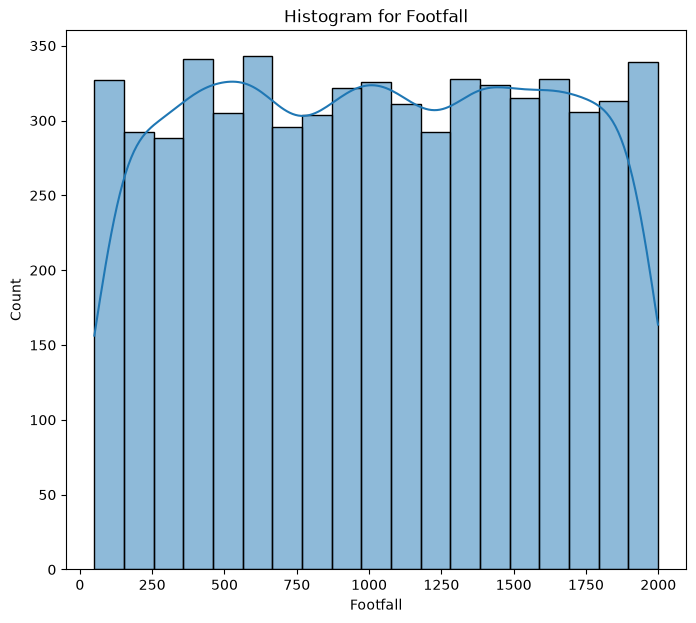

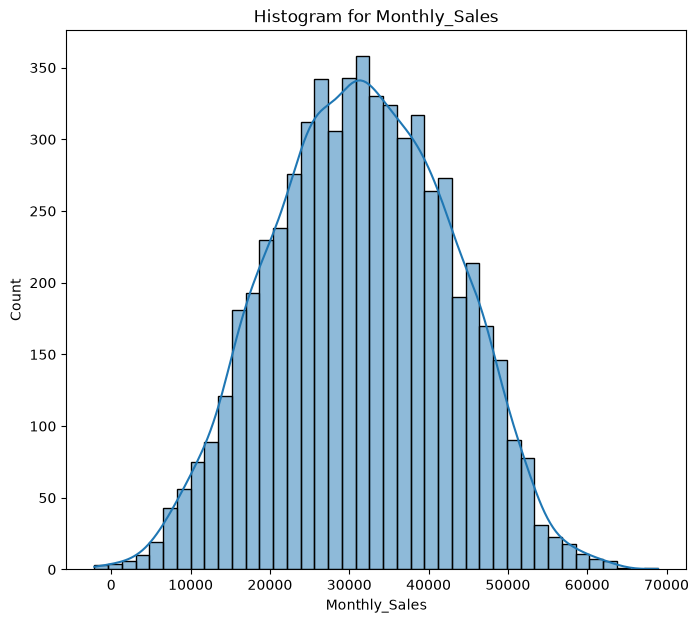

In [14]:
for col in df.columns:
    plt.figure(figsize=(8,7))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram for {col}")
    plt.show()

No missing values and potential outliers found in the data

## 2. Pre Processing data for the Multiple Linear Regression Model

In [15]:
feature = ["Advertising_Spend", "Social_Media_Spend", "Store_Size", "Footfall"]
target = "Monthly_Sales"

X = df[feature]
y = df[target]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4800, 4)
(1200, 4)
(4800,)
(1200,)


## 3. Training the model

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 3.46, 2.9 , 1.28,15.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Advertising_Spend','Social_Media_Spend','Store_Size','Footfall']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-129.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [19]:
print("Intercept: ", model.intercept_)
print("\n Coefficients: \n ", pd.Series(model.coef_, index=X_train.columns))

Intercept:  -129.43324005194518

 Coefficients: 
  Advertising_Spend      3.456612
Social_Media_Spend     2.902113
Store_Size             1.281225
Footfall              15.065935
dtype: float64


## 4. Checking the parameters of the model

In [20]:
y_pred = model.predict(X_test)

In [21]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("R squared: ", r2)
print("Mean absolute error: ", mae)
print("Mean squared error: ", mse)
print("Root mean squared Error: ", rmse)

R squared:  0.8036368252297639
Mean absolute error:  3971.529196943319
Mean squared error:  24574825.076234784
Root mean squared Error:  4957.300180162059


## 5. Checking the actual values vs the predicted values

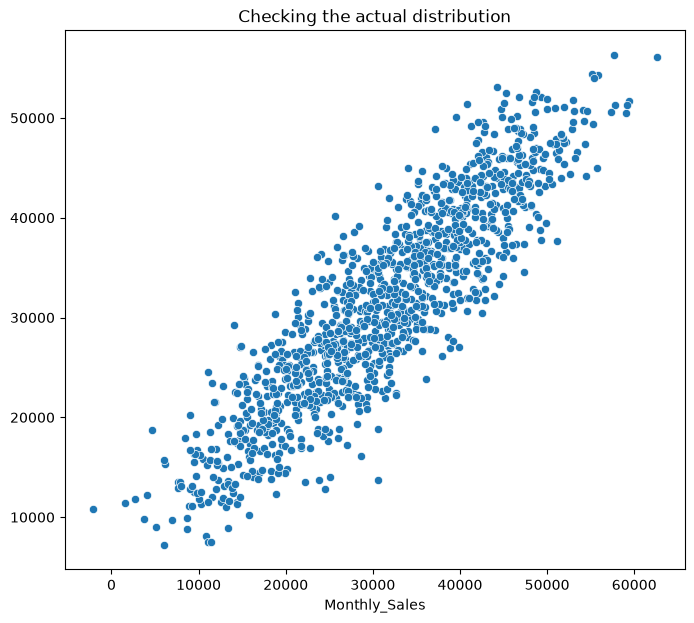

In [22]:
plt.figure(figsize=(8,7))
sns.scatterplot(x=y_test, y=y_pred, s=35)
plt.title("Checking the actual distribution")
plt.show()

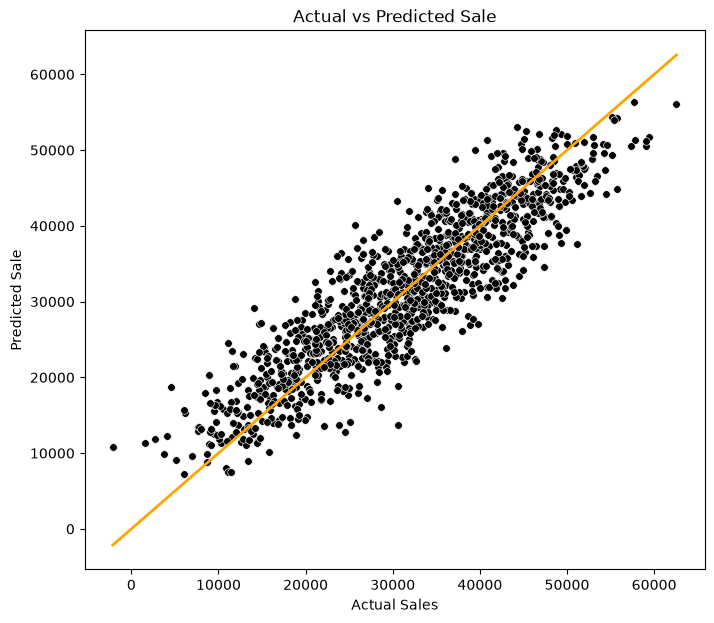

In [25]:
plt.figure(figsize=(8,7))
sns.scatterplot(x=y_test, y=y_pred, s=30, color="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, color="orange")
plt.title("Actual vs Predicted Sale")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sale")
plt.show()

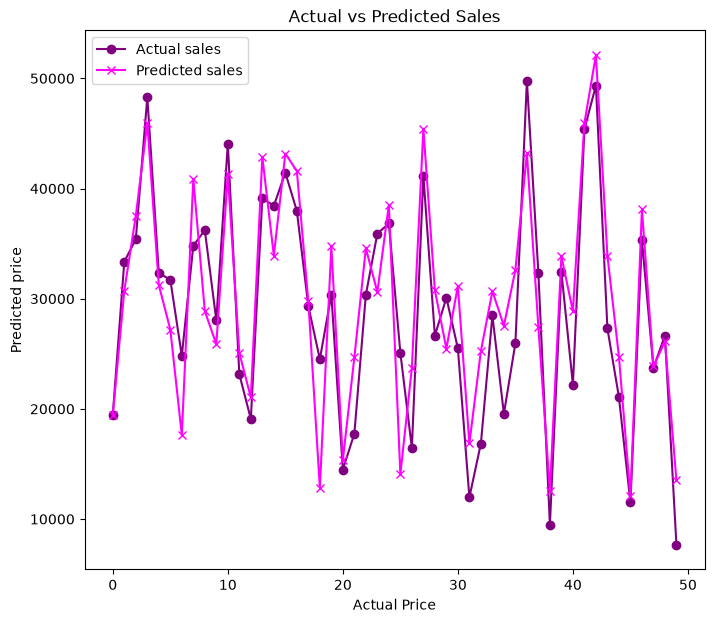

In [35]:
plt.figure(figsize=(8,7))
plt.plot(y_test.values[:50], label="Actual sales", color="purple", marker="o")
plt.plot(y_pred[:50], label="Predicted sales", color="magenta", marker="x")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Price")
plt.ylabel("Predicted price")
plt.legend()
plt.show()